# LAB 1 for CS4243: Textures and Materials
## Notebook 3 — DTD attribute prediction
> **Introduction.** This notebook is part of **LAB 1 for CS4243: Textures and Materials**. It trains and evaluates one-vs-rest attribute predictors on official DTD split 1 and visualises where handcrafted colour, Gabor, and edge statistics align—or fail to align—with human texture words.

## What this notebook tests
We use 13 terms spanning orientation, repetition, surface relief, irregular marks, and complex patterns. The primary folder label and joint annotations form a multi-label target. Training, validation, and test membership comes only from the supplied official split files.

## 1. Load the complete DTD manifest
For a responsive lab walkthrough we take three training and two validation images per selected primary term. Students should scale this up after verifying their implementation.

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from texturelab.config import FeatureConfig, GaborConfig
from texturelab.data import DTD_ATTRIBUTES, read_manifest
from texturelab.evaluation import evaluate_attributes
from texturelab.features import extract_local_features, global_pool
from texturelab.models import fit_attribute_classifier
from texturelab.supplied import load_image

attributes = list(DTD_ATTRIBUTES)
dtd = read_manifest(ROOT / "manifests" / "dtd_split1.csv")
size = (64, 64)
train_records = sum(
    (
        [r for r in dtd if r.split == "train" and r.attributes[0] == a]
        for a in attributes
    ),
    [],
)
validation_records = sum(
    (
        [r for r in dtd if r.split == "validation" and r.attributes[0] == a]
        for a in attributes
    ),
    [],
)
print(
    "complete manifest:",
    len(dtd),
    "walkthrough train:",
    len(train_records),
    "validation:",
    len(validation_records),
)

complete manifest: 5640 walkthrough train: 520 validation: 520


## 2. Visualise selected DTD attributes
One validation image per term illustrates the diversity within human-oriented attribute labels. Joint annotations may include several additional terms beyond the title.

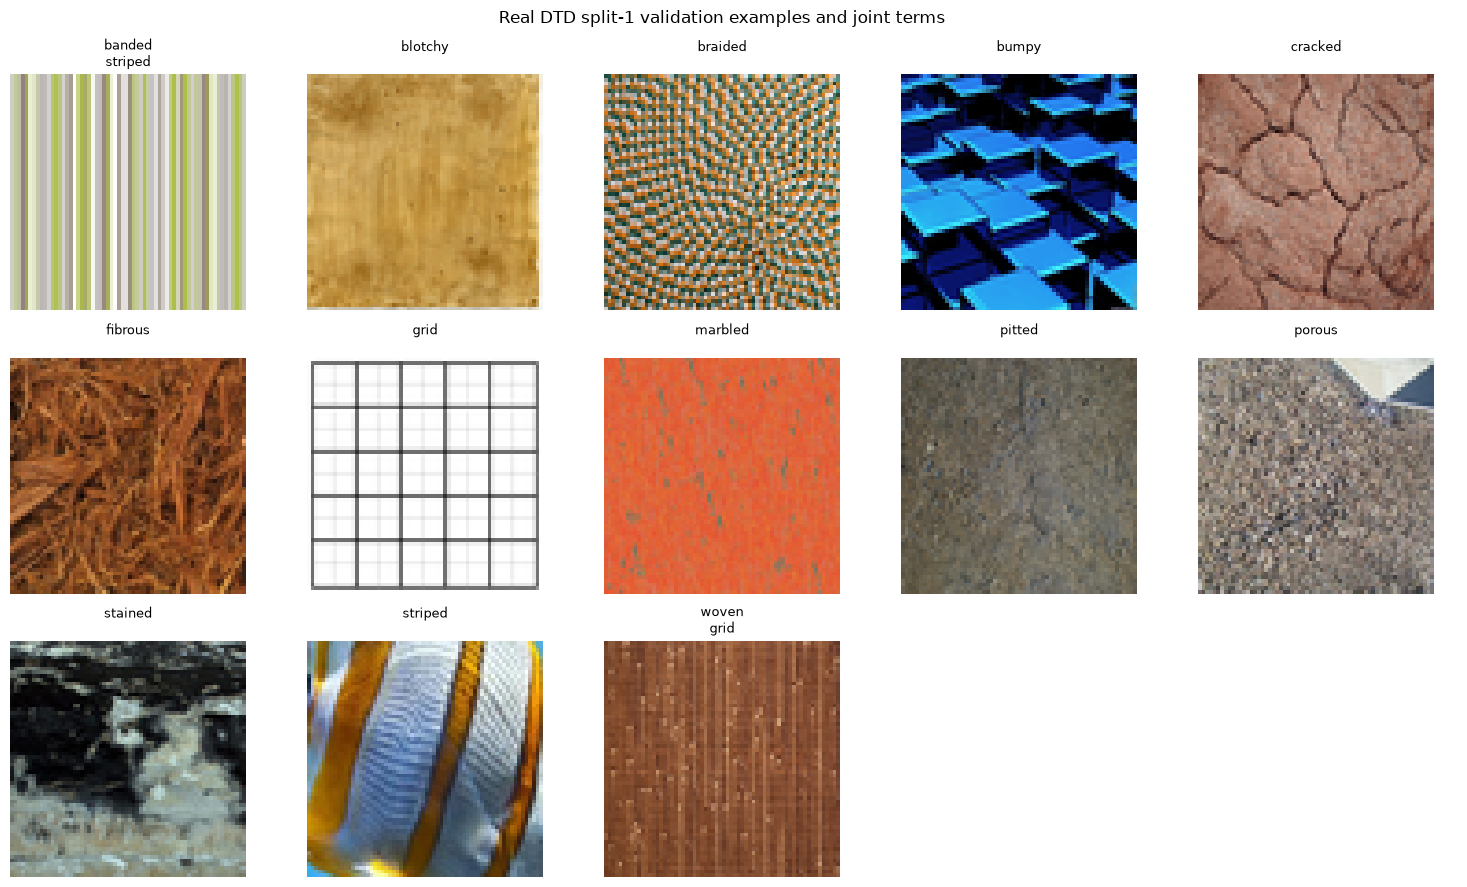

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()
for ax, attribute in zip(axes, attributes):
    record = next(r for r in validation_records if r.attributes[0] == attribute)
    ax.imshow(load_image(record.path, size))
    ax.set_title(attribute + "\n" + ", ".join(record.attributes[1:3]), fontsize=9)
    ax.axis("off")
for ax in axes[len(attributes) :]:
    ax.axis("off")
fig.suptitle("Real DTD split-1 validation examples and joint terms")
fig.tight_layout()

## 3. Extract the shared handcrafted representation
Complete both marked cells in this section. Each image must be resized consistently, converted to an aligned local feature map, and globally pooled using the existing `texturelab` tools. Your final arrays must preserve record order so every descriptor remains aligned with its multi-label target.

In [4]:
# YOUR CODE HERE
#
# TODO 1 — Configure the shared feature extractor
#   - Create a GaborConfig with frequencies (0.10, 0.22), orientations
#     (0, pi/2), kernel_size 11, and pool_size 7.
#   - Pass it into FeatureConfig and store the result in `config`.
#   - Use the default sine phase unless you are explicitly studying phases.
gabor_config = GaborConfig(
    frequencies=(0.10, 0.22),
    orientations=(0, np.pi / 2),
    kernel_size=11,
    pool_size=7,
)
config = FeatureConfig(gabor=gabor_config)
# TODO 2 — Implement one image-level descriptor
#   - Define `descriptor(record)`. Load record.path at the common `size`.
#   - Call extract_local_features(image, config); it returns a feature map
#     and channel names. Pool the feature map with global_pool().
#   - Return one one-dimensional descriptor; do not use labels here.
def descriptor(record):
    image = load_image(record.path, size)
    feature_map, channel_names = extract_local_features(image, config)
    pooled = global_pool(feature_map)
    return pooled

# TODO 3 — Build split-specific design matrices
#   - Apply descriptor() to train_records and validation_records in their
#     existing order, then stack the results as `x_train` and `x_validation`.
#   - Do not fit on or otherwise introduce test records in this section.
x_train = np.stack([descriptor(r) for r in train_records])
x_validation = np.stack([descriptor(r) for r in validation_records])

# TODO 4 — Encode the multi-label targets
#   - For each record and each name in `attributes`, write 1 when the name
#     occurs in record.attributes and 0 otherwise.
#   - Store integer matrices as `y_train` and `y_validation`; columns must
#     follow exactly the same order as `attributes`.
y_train = np.array(
    [[1 if a in r.attributes else 0 for a in attributes] for r in train_records],
    dtype=int,
)
y_validation = np.array(
    [[1 if a in r.attributes else 0 for a in attributes] for r in validation_records],
    dtype=int,
)

# TODO 5 — Audit the result
#   - Print descriptor/target shapes and the training positives per term.
#   - Check that x/y row counts agree and all descriptors are finite.
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_validation:", x_validation.shape, "y_validation:", y_validation.shape)

positives_per_term = y_train.sum(axis=0)
for name, count in zip(attributes, positives_per_term):
    print(f"{name:>15}: {count} positive training examples")
    
assert x_train.shape[0] == y_train.shape[0]
assert x_validation.shape[0] == y_validation.shape[0]
assert np.isfinite(x_train).all(), "non-finite values in x_train"
assert np.isfinite(x_validation).all(), "non-finite values in x_validation"




x_train: (520, 39) y_train: (520, 13)
x_validation: (520, 39) y_validation: (520, 13)
         banded: 44 positive training examples
        blotchy: 69 positive training examples
        braided: 41 positive training examples
          bumpy: 46 positive training examples
        cracked: 41 positive training examples
        fibrous: 42 positive training examples
           grid: 40 positive training examples
        marbled: 42 positive training examples
         pitted: 44 positive training examples
         porous: 45 positive training examples
        stained: 45 positive training examples
        striped: 54 positive training examples
          woven: 47 positive training examples


### PCA view of descriptor overlap
PCA is a visual diagnostic only—not a classifier or a source of model inputs. Complete the marked cell to compare training descriptors by primary attribute. Overlap suggests that a linear predictor may find those attributes difficult to separate.

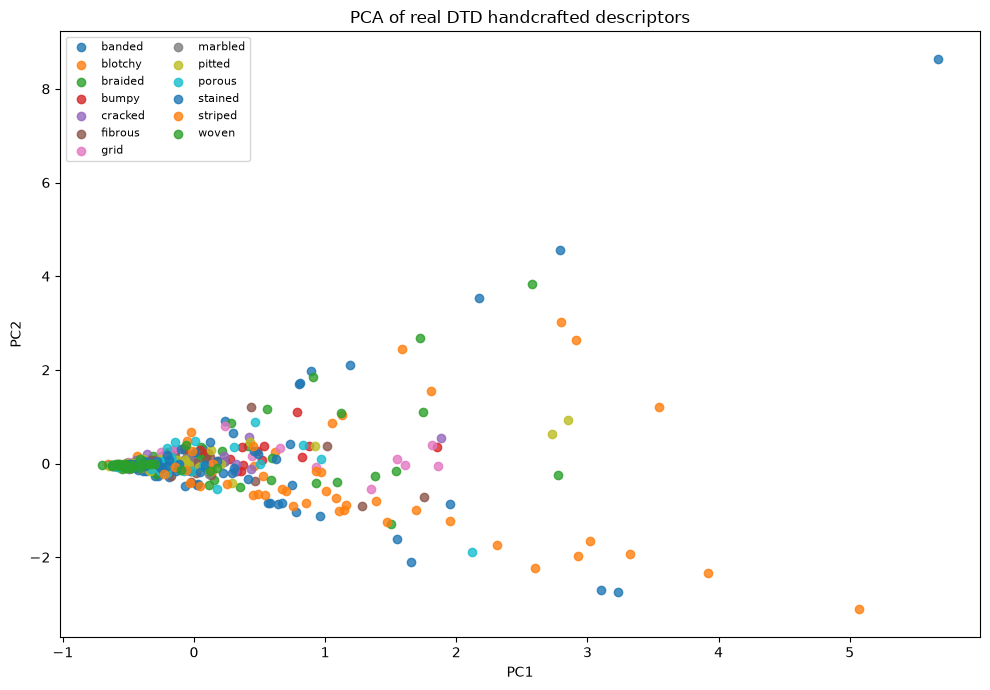

In [5]:
# YOUR CODE HERE
#
# TODO 1 — Fit a two-dimensional diagnostic projection
#   - Stack x_train and x_validation before fitting PCA(n_components=2).
#   - Use the fit_transform() method to project the stacked descriptors.
#   - Keep the first len(x_train) projected rows as `train_projection`.
#   - PCA may inspect validation descriptors for this visual only; the
#     attribute classifier in Section 4 must still fit on training data only.
x_stacked = np.vstack([x_train, x_validation])
pca = PCA(n_components=2)
projected = pca.fit_transform(x_stacked)
train_projection = projected[: len(x_train)]
# TODO 2 — Recover plotting labels
#   - Build `primary` from the first entry of each training record's
#     attributes tuple. Its length must equal len(train_projection).
primary = np.array([r.attributes[0] for r in train_records])

fig, ax = plt.subplots(figsize=(10, 7))
for attribute in attributes:
    selected = primary == attribute
    ax.scatter(
        train_projection[selected, 0],
        train_projection[selected, 1],
        label=attribute,
        alpha=0.8,
    )
ax.set(title="PCA of real DTD handcrafted descriptors", xlabel="PC1", ylabel="PC2")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## 4. Fit scikit-learn one-vs-rest predictors
Use the supplied model helper rather than implementing logistic regression. `StandardScaler` is already fitted inside its training pipeline, and each estimator learns one attribute independently. Fit only on training data, evaluate unchanged validation probabilities, and save a self-describing Task C bundle for Notebook 4.

In [6]:
# YOUR CODE HERE
#
# TODO 1 — Fit the supplied one-vs-rest classifier
#   - Call fit_attribute_classifier(..) with x_train, y_train, attributes,
#     and C=2.0. Store the fitted estimator as `attribute_model`.
#   - Do not pass validation data to the fitting helper.
attribute_model = fit_attribute_classifier(x_train, y_train, attributes, C=2.0)

# TODO 2 — Predict and evaluate on validation
#   - predict the probability of x_validation and store the N-by-A result as
#     `validation_probability`. Column order must match `attributes`.
#   - Use evaluate_attributes() to create `attribute_report` and present 
#     its results.
validation_probability = attribute_model.predict_proba(x_validation)
attribute_report = evaluate_attributes(y_validation, validation_probability, attributes)
print(attribute_report)

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
task_c_model_path = MODEL_DIR / "task_c_attribute_model.joblib"
joblib.dump(
    {
        "attribute_classifier": attribute_model,
        "feature_config": config,
        "attributes": attributes,
        "image_size": size,
    },
    task_c_model_path,
)
print("Saved frozen Task C model to:", task_c_model_path)

{'macro_average_precision': 0.22356725270367692, 'macro_f1': 0.1184186635950773, 'per_attribute': {'banded': {'average_precision': 0.4277976970882009, 'f1': 0.45901639344262296, 'positives': 41}, 'blotchy': {'average_precision': 0.193132723642491, 'f1': 0.0, 'positives': 70}, 'braided': {'average_precision': 0.14422526756867485, 'f1': 0.0, 'positives': 42}, 'bumpy': {'average_precision': 0.1592557026986216, 'f1': 0.0425531914893617, 'positives': 43}, 'cracked': {'average_precision': 0.12189179936501195, 'f1': 0.0, 'positives': 40}, 'fibrous': {'average_precision': 0.13107567156519884, 'f1': 0.0, 'positives': 43}, 'grid': {'average_precision': 0.2521067605492895, 'f1': 0.23728813559322035, 'positives': 41}, 'marbled': {'average_precision': 0.21448372303461874, 'f1': 0.0, 'positives': 43}, 'pitted': {'average_precision': 0.08113154132826886, 'f1': 0.0, 'positives': 43}, 'porous': {'average_precision': 0.11108229921692025, 'f1': 0.0, 'positives': 45}, 'stained': {'average_precision': 0.17

## 5. Visualise per-attribute performance
Complete both marked cells. Average precision assesses ranking quality under imbalance, while thresholded F1 additionally depends on the chosen probability cutoff. Report both rather than interpreting either metric in isolation.

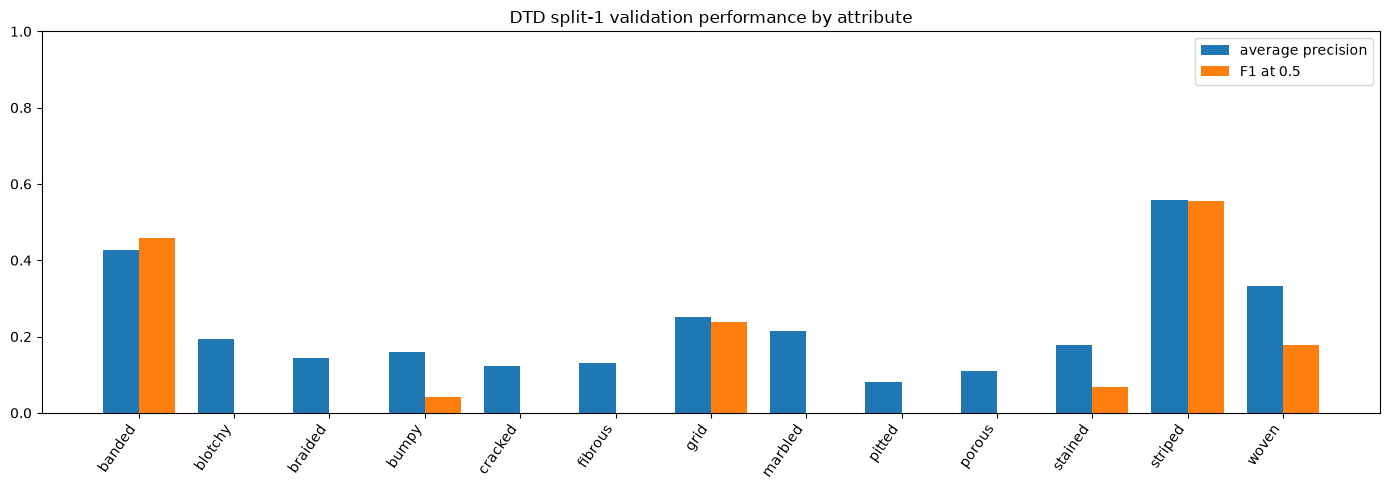

In [7]:
# YOUR CODE HERE
#
# TODO 1 — Extract aligned metric vectors
#   - In `attributes` order, collect `average_precision` and `f1` from
#     attribute_report['per_attribute']; store them as `ap` and `f1`.
ap = [attribute_report['per_attribute'][a]['average_precision'] for a in attributes]
f1 = [attribute_report['per_attribute'][a]['f1'] for a in attributes]

x = np.arange(len(attributes))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width / 2, ap, width, label="average precision")
ax.bar(x + width / 2, f1, width, label="F1 at 0.5")
ax.set_xticks(x, attributes, rotation=55, ha="right")
ax.set_ylim(0, 1)
ax.set_title("DTD split-1 validation performance by attribute")
ax.legend()
fig.tight_layout()

## 6. Qualitative prediction inspection
For one validation image from every selected primary class, view the photograph beside all predicted attribute probabilities. Showing all 13 primary classes avoids drawing conclusions from only a few convenient examples and is essential for explaining why orientation-based attributes succeed while complex visual attributes fail.

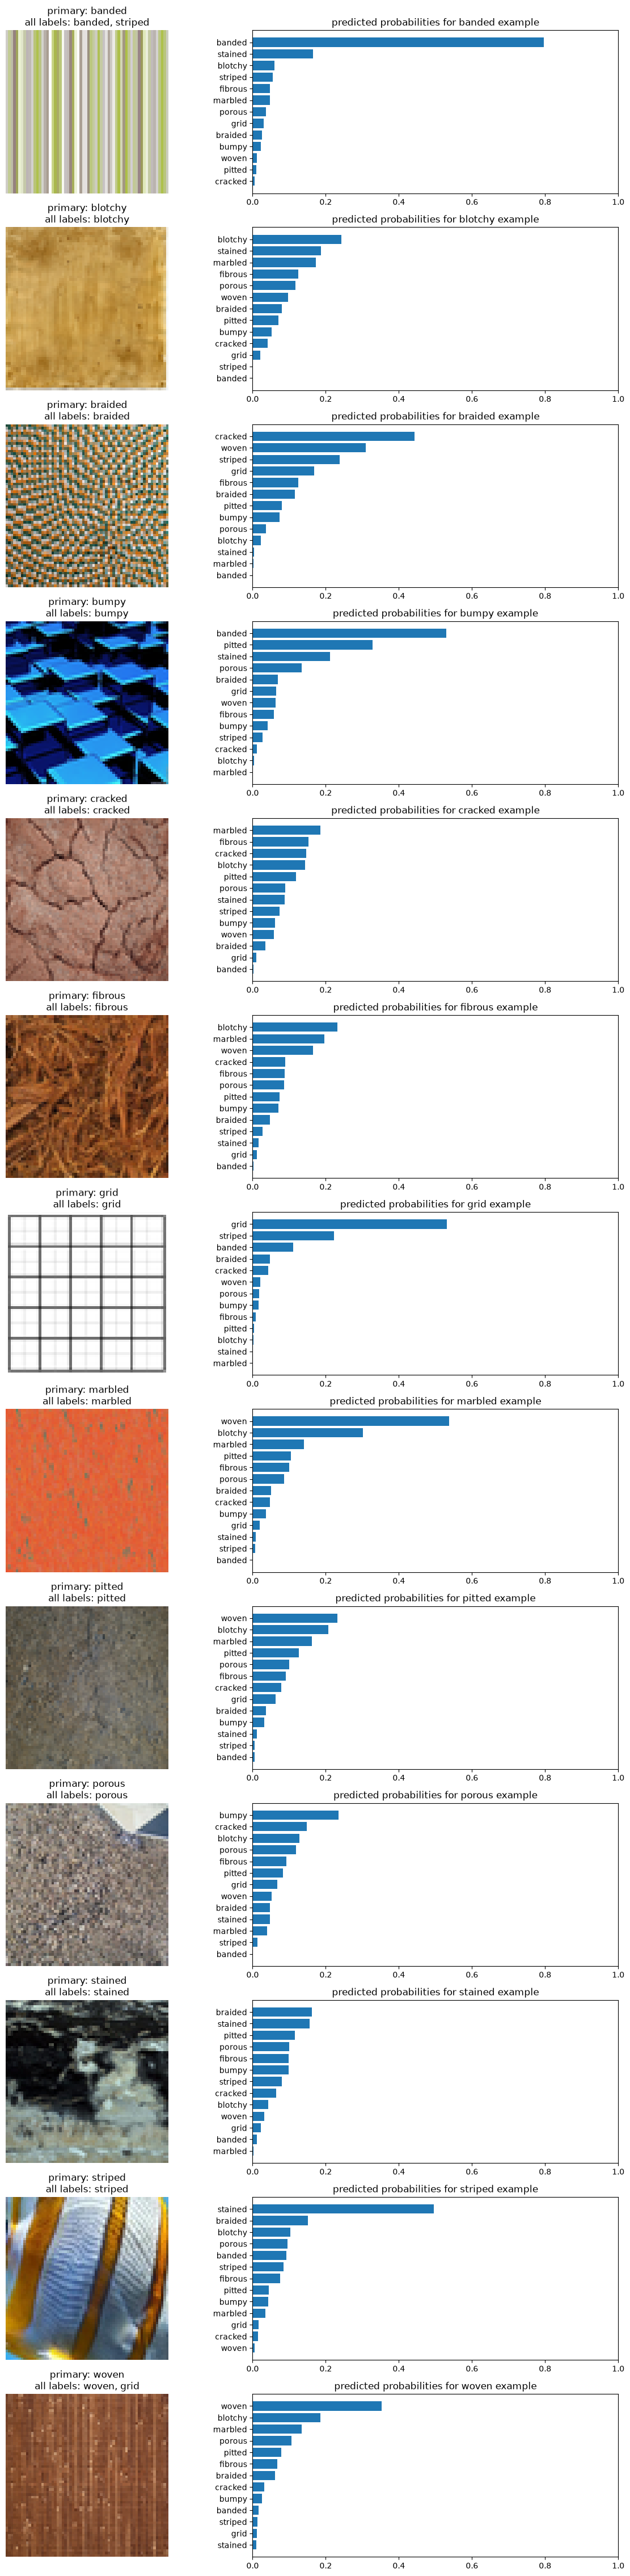

In [8]:
indices = [
    next(
        index
        for index, record in enumerate(validation_records)
        if record.attributes[0] == attribute
    )
    for attribute in attributes
]
fig, axes = plt.subplots(len(indices), 2, figsize=(13, 3.5 * len(indices)))
for row_index, index in enumerate(indices):
    record = validation_records[index]
    axes[row_index, 0].imshow(load_image(record.path, size))
    axes[row_index, 0].set_title(
        f"primary: {record.attributes[0]}\nall labels: " + ", ".join(record.attributes)
    )
    axes[row_index, 0].axis("off")
    order = np.argsort(validation_probability[index])
    axes[row_index, 1].barh(
        np.array(attributes)[order], validation_probability[index, order]
    )
    axes[row_index, 1].set_xlim(0, 1)
    axes[row_index, 1].set_title(
        f"predicted probabilities for {record.attributes[0]} example"
    )
fig.tight_layout()